# 🏏 IPL Match Data Analysis (2008–2024)

![IPL Image](ipl.jpg)

## INTRODUCTION

**Project Overview**

The IPL Complete Dataset (2008-2024) is the latest and complete Indian Premier League dataset, updated till the 2024 season. This study utilizes the dataset to analyze match descriptions, results, winners, player of the matches, and ball-by-ball details. Starting with data sourced from Cricsheet, the dataset provides comprehensive coverage of every IPL season. Through exploratory data analysis (EDA), the research identifies patterns in match outcomes, team performances, and player statistics, providing valuable information for cricket analysts and enthusiasts. The study aims to highlight growth trends and identify top-performing teams and players in IPL history.

## Here's a summary of the libraries used:

**NumPy:** Ideal for mathematical computations, it handles multidimensional data, making it suitable for processing large ball-by-ball datasets.

**Pandas:** Built on NumPy, it provides high-level data structures like Series and DataFrames for effective data analysis and manipulation of match and delivery records.

**Matplotlib:** A versatile library for creating static, animated, and interactive visualizations, offering extensive customization options for different types of plots.

**Seaborn:** Built on Matplotlib, it simplifies the creation of statistical graphics, integrating well with pandas DataFrames for enhanced data exploration and visualization.

---
## Import Libraries

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---
## Load the Data


In [24]:
matches    = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

print('matches shape    :', matches.shape)      # (rows, columns)
print('deliveries shape :', deliveries.shape)

matches shape    : (1095, 20)
deliveries shape : (260920, 17)


In [25]:
# Shows the first 5 rows 
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [26]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


---
## Data Cleaning

### Check for Missing Values

In [27]:
print('=== Missing values in matches ===')
print(matches.isnull().sum())
print()
print('=== Missing values in deliveries ===')
print(deliveries.isnull().sum())

=== Missing values in matches ===
id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

=== Missing values in deliveries ===
match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fie

### Drop Unnecessary / Mostly-Null Columns

In [28]:
# Drop columns that are almost always empty or not needed for analysis
cols_to_drop = [c for c in ['method', 'umpire1', 'umpire2'] if c in matches.columns]
matches.drop(columns=cols_to_drop, inplace=True)

print('Remaining columns:', list(matches.columns))

Remaining columns: ['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over']


## Fix Data Types

In [29]:
# Convert 'date' column to datetime so we can sort/filter by date
matches['date'] = pd.to_datetime(matches['date'])

print(matches[['date']].dtypes)

date    datetime64[ns]
dtype: object


### Handle Missing Values

In [30]:
# Rows where 'winner' is null = abandoned / no result — drop them
matches.dropna(subset=['winner'], inplace=True)

# Fill missing city with 'Unknown'
if 'city' in matches.columns:
    matches['city'].fillna('Unknown', inplace=True)

# In deliveries: fill missing extra / dismissal info
deliveries['extras_type'].fillna('none', inplace=True)
deliveries['dismissal_kind'].fillna('not out', inplace=True)
deliveries['player_dismissed'].fillna('none', inplace=True)

print('Missing values after cleaning:')
print('  matches   :', matches.isnull().sum().sum())
print('  deliveries:', deliveries.isnull().sum().sum())

Missing values after cleaning:
  matches   : 14
  deliveries: 251566


### Remove Duplicates

In [31]:
print('Duplicate rows — matches   :', matches.duplicated().sum())
print('Duplicate rows — deliveries:', deliveries.duplicated().sum())

matches.drop_duplicates(inplace=True)
deliveries.drop_duplicates(inplace=True)

print('\nAfter removing duplicates:')
print('  matches shape   :', matches.shape)
print('  deliveries shape:', deliveries.shape)

Duplicate rows — matches   : 0
Duplicate rows — deliveries: 0

After removing duplicates:
  matches shape   : (1090, 17)
  deliveries shape: (260920, 17)


### Add Helper Column — toss_winner_won

In [32]:
# True if the team that won the toss also won the match
matches['toss_winner_won'] = matches['toss_winner'] == matches['winner']

print('Cleaned matches preview:')
matches.head(3)

Cleaned matches preview:


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,toss_winner_won
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,False
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,True
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,False


---
## Exploratory Data Analysis (EDA) & Visualizations

### Most Wins by Team

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Sunrisers Hyderabad             88
Kings XI Punjab                 88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Name: count, dtype: int64


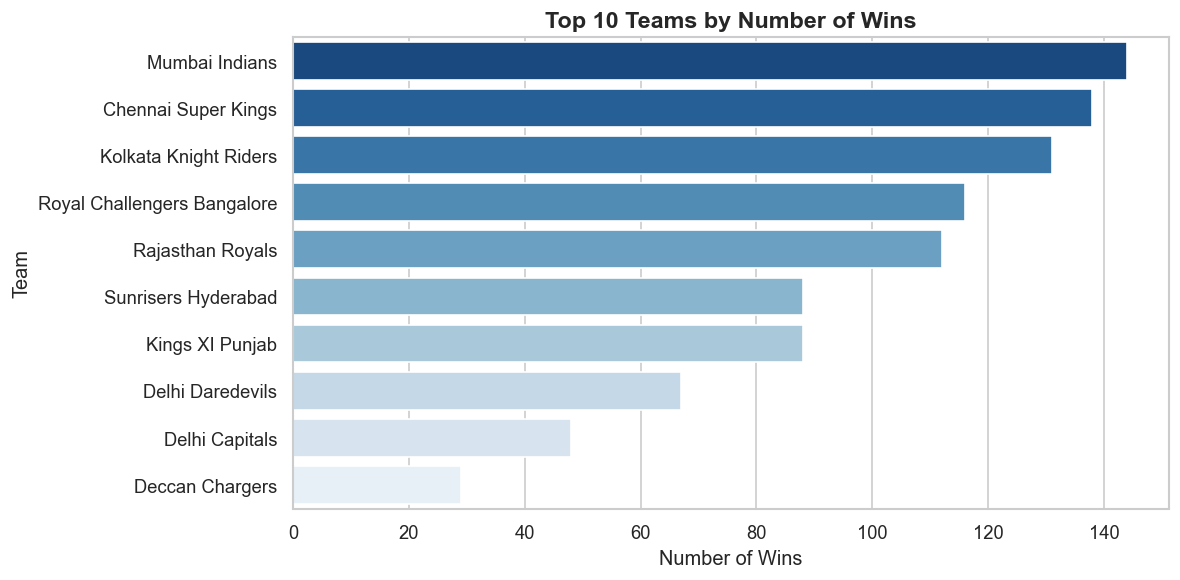

In [35]:
team_wins = matches['winner'].value_counts().head(10)

print(team_wins)

plt.figure(figsize=(10, 5))
sns.barplot(x=team_wins.values, y=team_wins.index,hue=team_wins.index, palette='Blues_r', legend=False )
plt.title('Top 10 Teams by Number of Wins', fontsize=14, fontweight='bold')
plt.xlabel('Number of Wins')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

### Toss Decision — Bat vs Field + Did Toss Help?

toss_decision
field    700
bat      390
Name: count, dtype: int64

Toss winner also won the match: 50.8% of the time


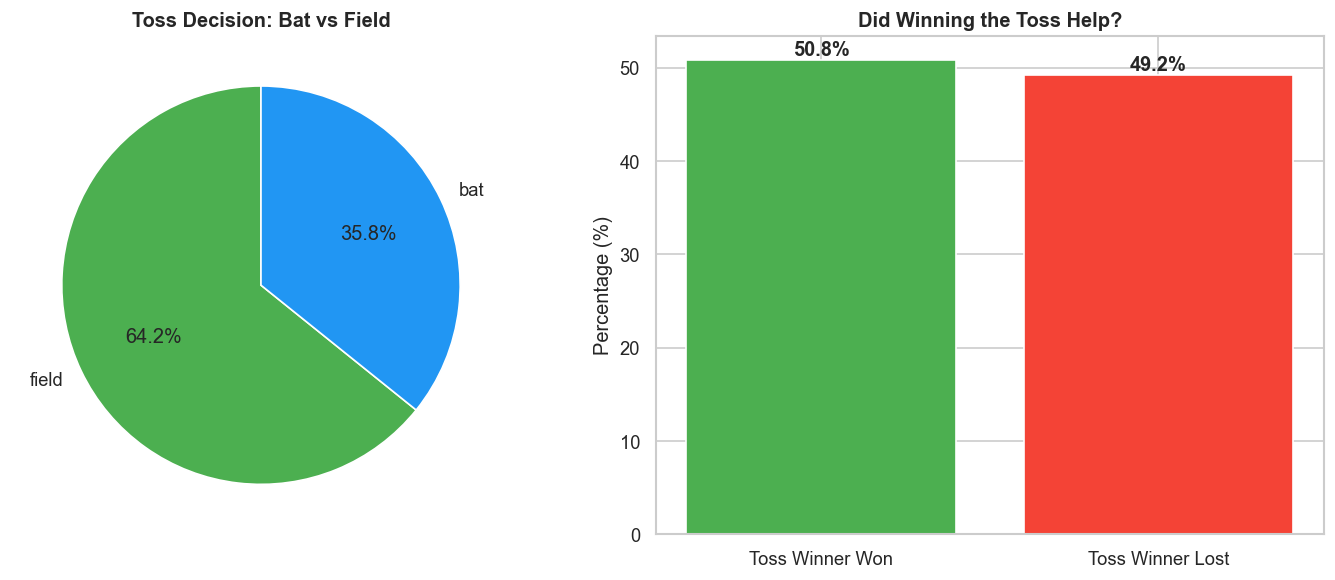

In [12]:
toss    = matches['toss_decision'].value_counts()
win_rate = matches['toss_winner_won'].mean() * 100

print(toss)
print(f'\nToss winner also won the match: {win_rate:.1f}% of the time')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart — toss decision
axes[0].pie(toss.values, labels=toss.index, autopct='%1.1f%%',
            colors=['#4CAF50', '#2196F3'], startangle=90)
axes[0].set_title('Toss Decision: Bat vs Field', fontweight='bold')

# Bar chart — did toss help?
axes[1].bar(['Toss Winner Won', 'Toss Winner Lost'],
            [win_rate, 100 - win_rate], color=['#4CAF50', '#f44336'])
axes[1].set_title('Did Winning the Toss Help?', fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
for i, v in enumerate([win_rate, 100 - win_rate]):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Top 10 Run-Scorers

batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64


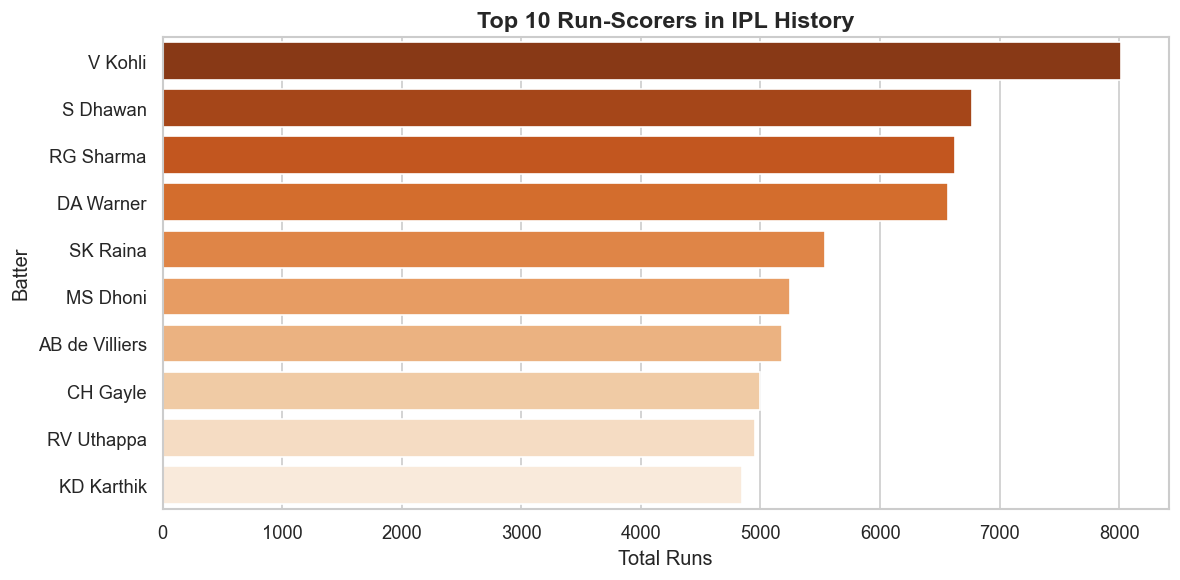

In [36]:
top_batters = (
    deliveries.groupby('batter')['batsman_runs']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_batters)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_batters.values, y=top_batters.index,hue=top_batters.index, palette='Oranges_r', legend=False)
plt.title('Top 10 Run-Scorers in IPL History', fontsize=14, fontweight='bold')
plt.xlabel('Total Runs')
plt.ylabel('Batter')
plt.tight_layout()
plt.show()

### Top 10 Wicket-Takers

bowler
YS Chahal     213
DJ Bravo      207
PP Chawla     201
SP Narine     200
R Ashwin      198
B Kumar       195
SL Malinga    188
A Mishra      183
JJ Bumrah     182
RA Jadeja     169
Name: is_wicket, dtype: int64


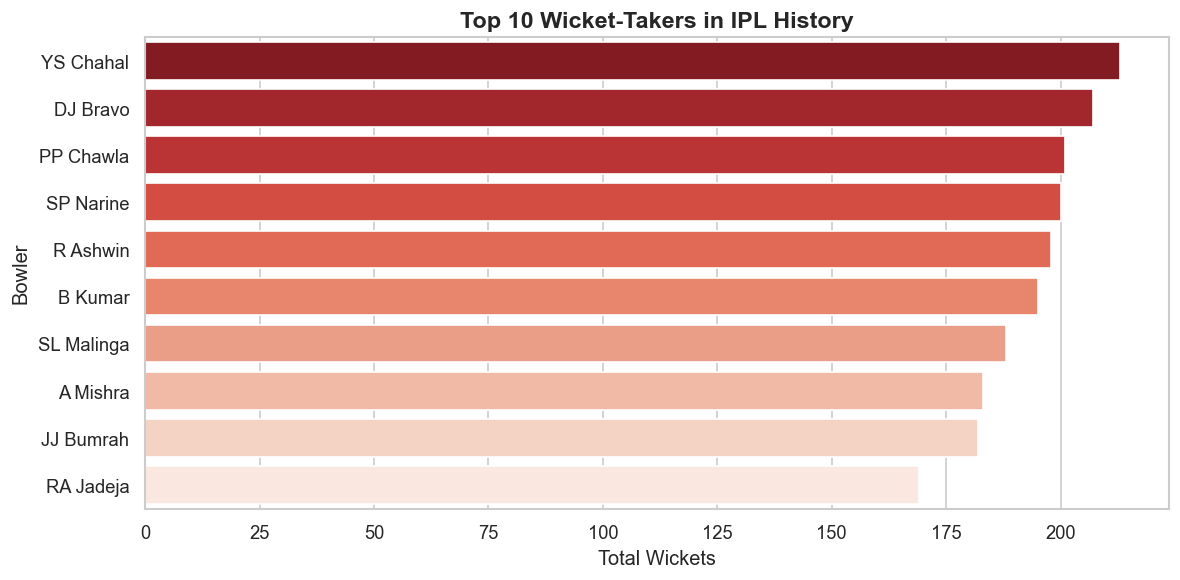

In [37]:
wickets = deliveries[deliveries['is_wicket'] == 1]

top_bowlers = (
    wickets.groupby('bowler')['is_wicket']
    .count()
    .sort_values(ascending=False)
    .head(10)
)

print(top_bowlers)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_bowlers.values, y=top_bowlers.index, hue=top_bowlers.index, palette='Reds_r', legend=False)
plt.title('Top 10 Wicket-Takers in IPL History', fontsize=14, fontweight='bold')
plt.xlabel('Total Wickets')
plt.ylabel('Bowler')
plt.tight_layout()
plt.show()

### Total Runs Per Season

season
2007/08    17937
2009       16353
2009/10    18883
2011       21098
2012       22453
2013       22602
2014       18931
2015       17964
2016       18862
2017       18786
2018       19901
2019       19331
2020/21    19416
2021       18637
2022       24395
2023       25563
2024       25971
Name: total_runs, dtype: int64


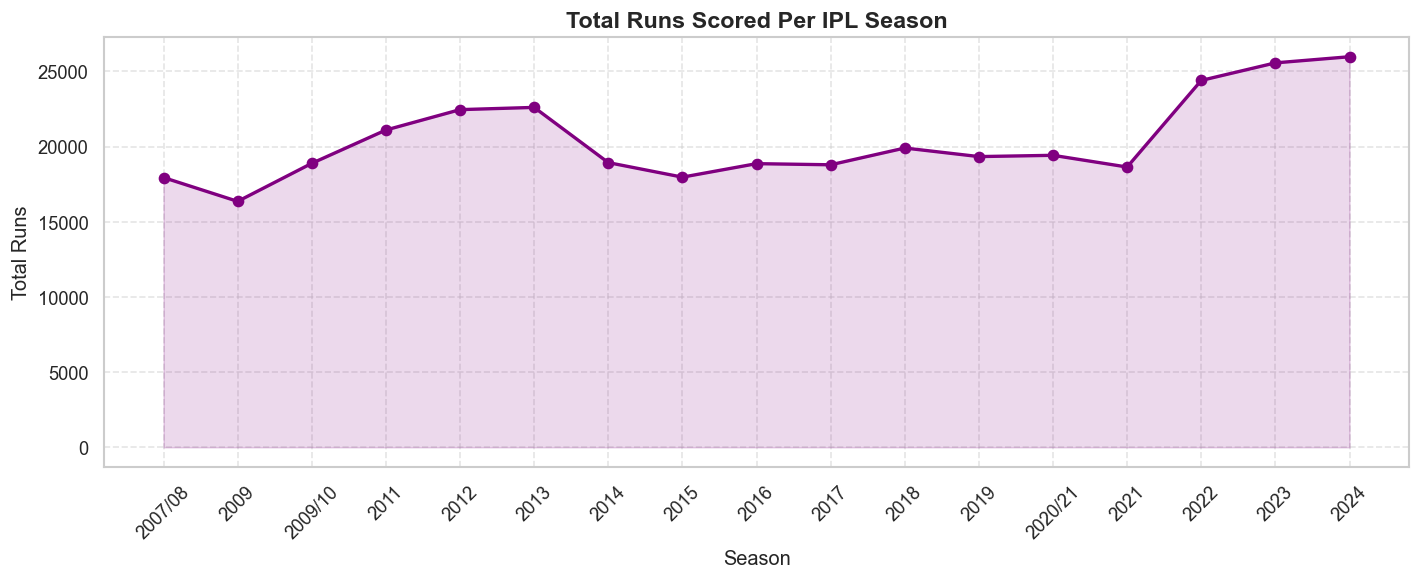

In [38]:
# Merge deliveries with matches to get the 'season' column
# merge() — joins two tables on a common key
merged = deliveries.merge(matches[['id', 'season']], left_on='match_id', right_on='id')

season_runs = (
    merged.groupby('season')['total_runs']
    .sum()
    .sort_index()
)

print(season_runs)

plt.figure(figsize=(12, 5))
plt.plot(season_runs.index, season_runs.values, marker='o', color='purple', linewidth=2)
plt.fill_between(season_runs.index, season_runs.values, alpha=0.15, color='purple')
plt.title('Total Runs Scored Per IPL Season', fontsize=14, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Total Runs')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Types of Dismissals

dismissal_kind
caught                   8063
bowled                   2212
run out                  1114
lbw                       800
caught and bowled         367
stumped                   358
retired hurt               15
hit wicket                 15
obstructing the field       3
retired out                 3
Name: count, dtype: int64


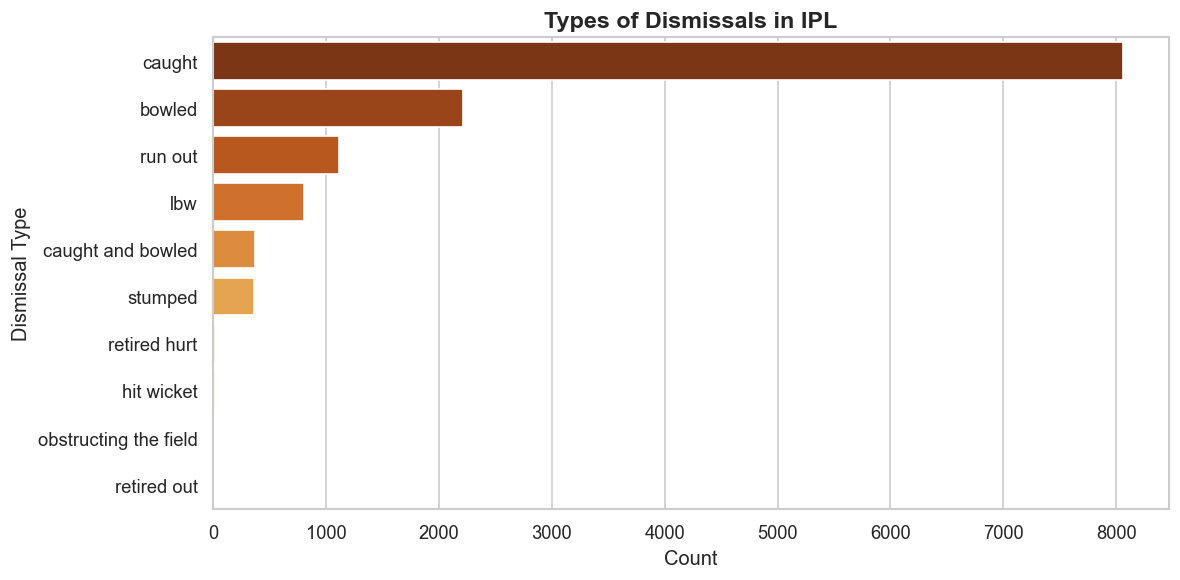

In [39]:
# Exclude 'not out' — only actual dismissals
actual_dismissals = wickets['dismissal_kind'].value_counts()

print(actual_dismissals)

plt.figure(figsize=(10, 5))
sns.barplot(x=actual_dismissals.values, y=actual_dismissals.index, hue=actual_dismissals.index, palette='YlOrBr_r', legend=False)
plt.title('Types of Dismissals in IPL', fontsize=14, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Dismissal Type')
plt.tight_layout()
plt.show()

### Top 10 Venues by Matches Hosted

venue
Eden Gardens                                  77
Wankhede Stadium                              73
M Chinnaswamy Stadium                         63
Feroz Shah Kotla                              59
Rajiv Gandhi International Stadium, Uppal     49
MA Chidambaram Stadium, Chepauk               48
Sawai Mansingh Stadium                        47
Dubai International Cricket Stadium           46
Wankhede Stadium, Mumbai                      45
Punjab Cricket Association Stadium, Mohali    35
Name: count, dtype: int64


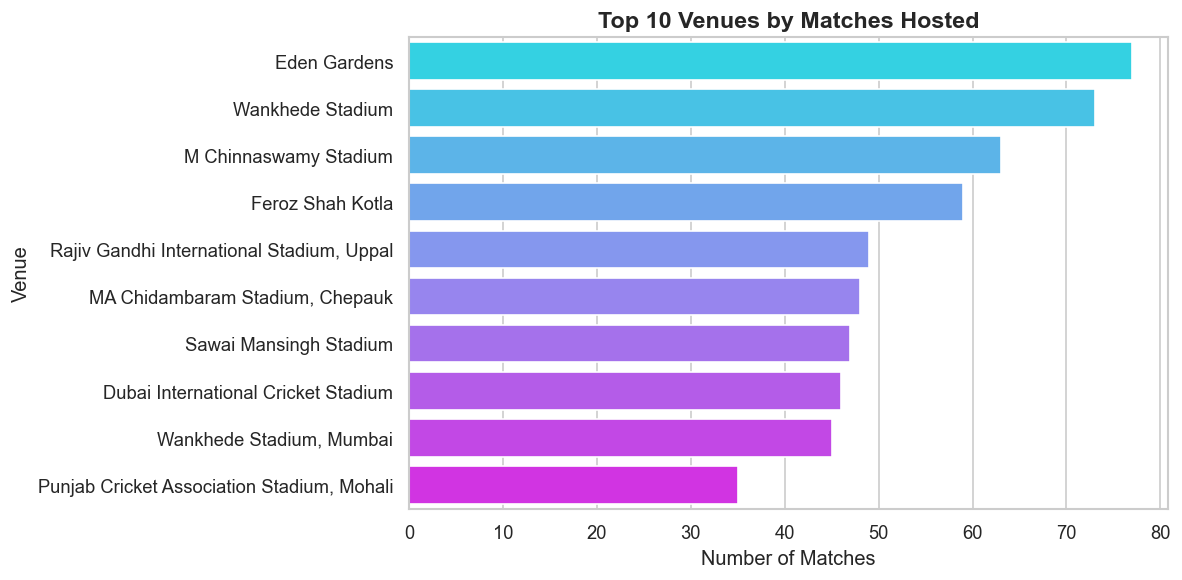

In [40]:
top_venues = matches['venue'].value_counts().head(10)

print(top_venues)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_venues.values, y=top_venues.index, hue=top_venues.index, palette='cool', legend=False)
plt.title('Top 10 Venues by Matches Hosted', fontsize=14, fontweight='bold')
plt.xlabel('Number of Matches')
plt.ylabel('Venue')
plt.tight_layout()
plt.show()

### Most Player of the Match Awards

player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         19
V Kohli           18
DA Warner         18
MS Dhoni          17
YK Pathan         16
RA Jadeja         16
SR Watson         16
AD Russell        15
Name: count, dtype: int64


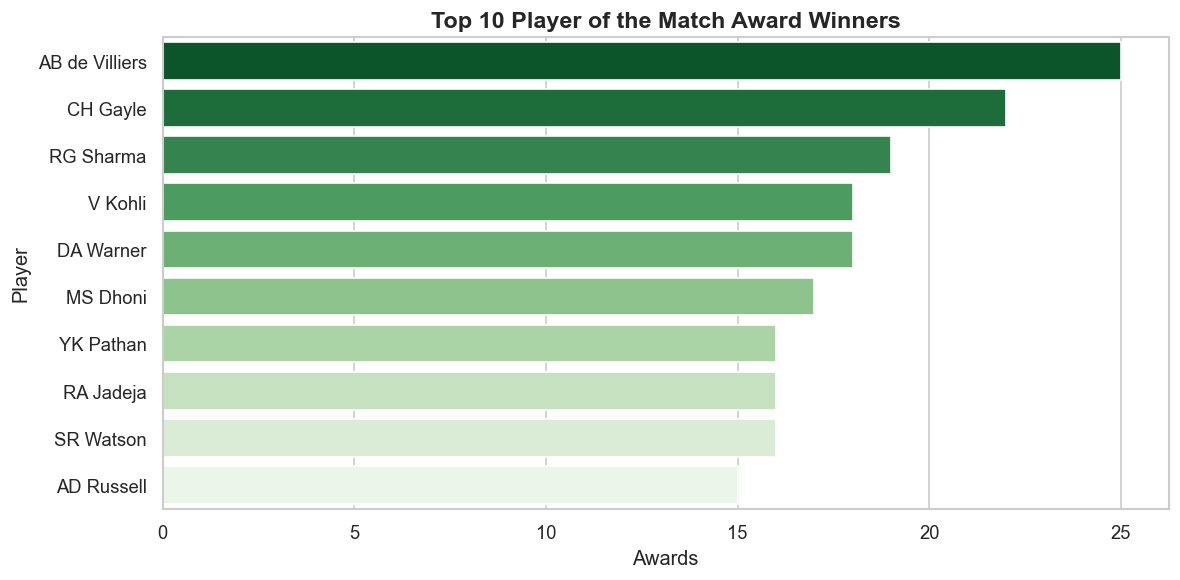

In [41]:
top_potm = matches['player_of_match'].value_counts().head(10)

print(top_potm)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_potm.values, y=top_potm.index, hue=top_potm.index, palette='Greens_r', legend=False)
plt.title('Top 10 Player of the Match Award Winners', fontsize=14, fontweight='bold')
plt.xlabel('Awards')
plt.ylabel('Player')
plt.tight_layout()
plt.show()

### Win Margin Distribution (Runs vs Wickets)

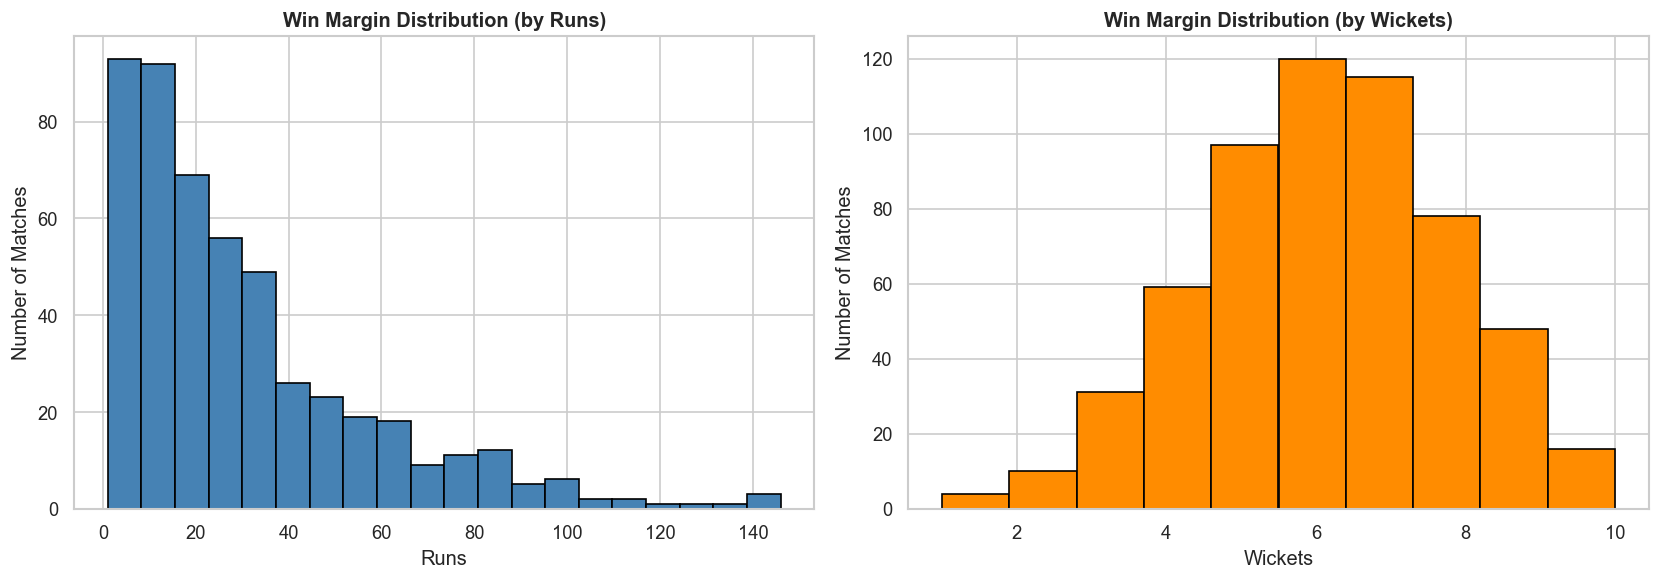

In [20]:
win_by_runs    = matches[matches['result'] == 'runs']['result_margin'].dropna()
win_by_wickets = matches[matches['result'] == 'wickets']['result_margin'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(win_by_runs, bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Win Margin Distribution (by Runs)', fontweight='bold')
axes[0].set_xlabel('Runs')
axes[0].set_ylabel('Number of Matches')

axes[1].hist(win_by_wickets, bins=10, color='darkorange', edgecolor='black')
axes[1].set_title('Win Margin Distribution (by Wickets)', fontweight='bold')
axes[1].set_xlabel('Wickets')
axes[1].set_ylabel('Number of Matches')

plt.tight_layout()
plt.show()

### Boundary Analysis — 4s vs 6s Per Season

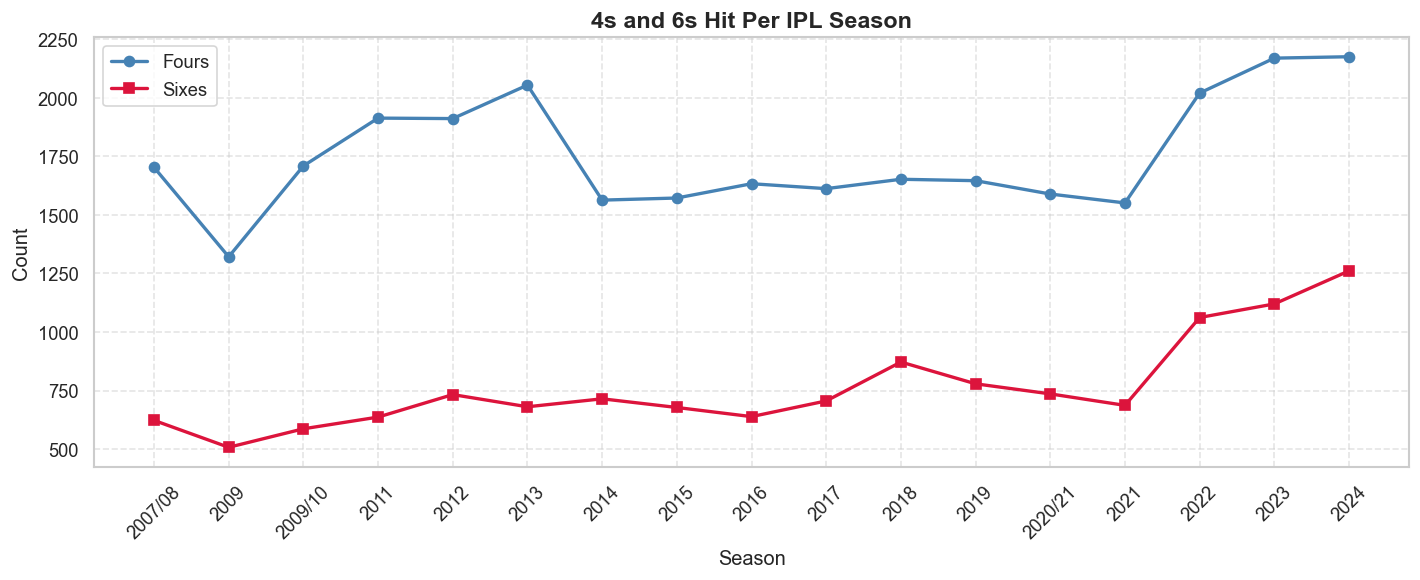

In [42]:
fours = deliveries[deliveries['batsman_runs'] == 4]
sixes = deliveries[deliveries['batsman_runs'] == 6]

# Merge with matches to get season
fours_season = fours.merge(matches[['id', 'season']], left_on='match_id', right_on='id')
sixes_season = sixes.merge(matches[['id', 'season']], left_on='match_id', right_on='id')

fours_per_season = fours_season.groupby('season').size()
sixes_per_season = sixes_season.groupby('season').size()

plt.figure(figsize=(12, 5))
plt.plot(fours_per_season.index, fours_per_season.values,
         marker='o', label='Fours', color='steelblue', linewidth=2)
plt.plot(sixes_per_season.index, sixes_per_season.values,
         marker='s', label='Sixes', color='crimson', linewidth=2)
plt.title('4s and 6s Hit Per IPL Season', fontsize=14, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---
## Summary of Key Findings

| # | Analysis | Finding |
|---|----------|---------|
| 1 | Team Wins | **Mumbai Indians** lead with the most wins |
| 2 | Toss Decision | ~64% of teams choose to **field first** after winning the toss |
| 3 | Toss Impact | Toss winner wins only **~50%** of matches — barely an advantage |
| 4 | Top Batter | **Virat Kohli** leads with 8,000+ runs all time |
| 5 | Top Bowler | **YS Chahal** leads all wicket-takers in IPL history |
| 6 | Season Runs | Run scoring has **increased steadily** each season |
| 7 | Dismissals | **Caught** is the most common dismissal (~62% of all wickets) |
| 8 | Venues | **Eden Gardens** and **Wankhede Stadium** host the most games |